In [8]:
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
import numpy as np
def use_svg_display():
    matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
def set_figsize(figsize=(6, 4), fontsize=16):
    use_svg_display()
    plt.rcParams['figure.figsize'] = figsize
    plt.rcParams['font.size'] = fontsize
set_figsize()

## 高维空间中数据的稀疏性

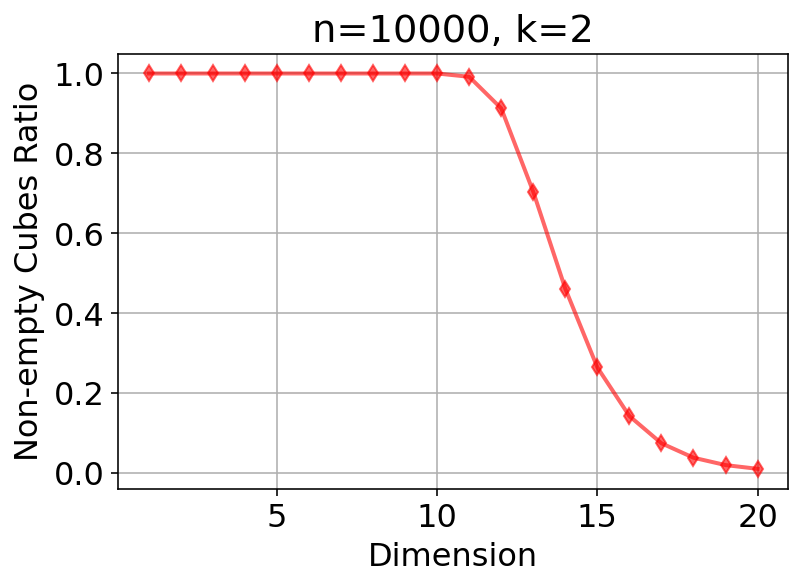

In [9]:
def generate_data(n, d):
    return np.random.rand(n, d)

def count_nonempty_cubes(data, k):
    digitized_data = (data * k).astype(int)
    unique_cubes = len(np.unique(digitized_data, axis=0))
    return unique_cubes

def experiment(n, d_range, k):
    nonempty_ratios = []
    for d in d_range:
        data = generate_data(n, d)
        nonempty_cubes = count_nonempty_cubes(data, k)
        nonempty_ratios.append(nonempty_cubes / (k ** d))
    return nonempty_ratios

n = 10000
d_range = range(1, 21)
k = 2
nonempty_ratios_2 = experiment(n, d_range, k)

# plt.figure() 
set_figsize()
plt.plot(d_range, nonempty_ratios_2, 'd-', c='r', lw=2, alpha=0.6)
plt.xlabel('Dimension')
plt.ylabel('Non-empty Cubes Ratio')
plt.title(f'n={n}, k={k}')
plt.grid()
# plt.savefig('Non-empty Cubes Ratio.pdf', bbox_inches='tight')
plt.show()

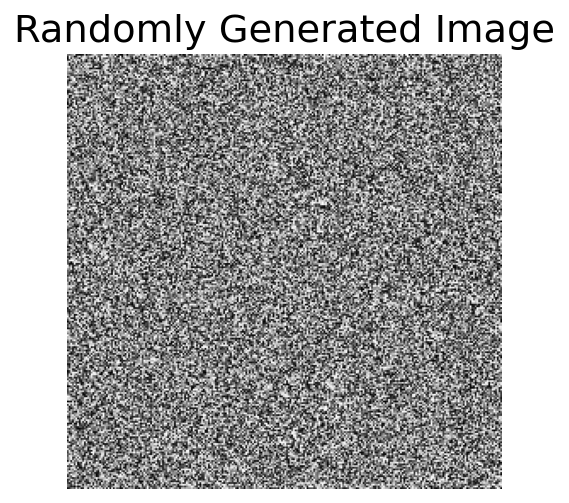

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
# from transformers import GPT2Tokenizer, GPT2LMHeadModel

# 实验1:随机图像生成
def generate_random_image(shape):
    return np.random.rand(*shape)

def display_image(image, title):
    # plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.title("Randomly Generated Image")
    # plt.show()

# 生成随机图像
set_figsize()
image_shape = (256, 256)
random_image = generate_random_image(image_shape)
display_image(random_image, 'Random Image')
# plt.savefig('random-image.pdf', bbox_inches='tight')

In [17]:
import numpy as np
import string

# 实验2:随机文本生成(简化版)
def generate_random_text_simple(vocab_size, length):
    vocab = string.ascii_letters + string.digits + string.punctuation + ' '
    indices = np.random.randint(0, vocab_size, length)
    return ''.join([vocab[i] for i in indices])

# 生成随机文本
vocab_size = len(string.ascii_letters + string.digits + string.punctuation + ' ')
text_length = 50
random_text = generate_random_text_simple(vocab_size, text_length)
print('Random Text:')
print(random_text)

# 自然语言文本示例
natural_text = "Deep learning is a subfield of machine learning that has revolutionized various domains, including computer vision, natural language processing, and speech recognition."
print('\nNatural Language Text:') 
print(natural_text)

Random Text:
x`gI>Xasyu=~[=g9#p DeGJt:ZVb1vfMM/tanXS@-1Q93T|#+5

Natural Language Text:
Deep learning is a subfield of machine learning that has revolutionized various domains, including computer vision, natural language processing, and speech recognition.


## 体积集中在表面

In [30]:
import math

def unit_ball_volume(d):
    """
    计算d维单位球的体积
    """
    if d % 2 == 0:
        return math.pi ** (d / 2) / math.factorial(d // 2)
    else:
        return 2 * math.pi ** ((d - 1) / 2) * math.factorial((d - 1) // 2) / math.factorial(d)

def inner_ball_volume_ratio(d, epsilon):
    """
    计算d维空间中半径为1-epsilon的内球体积与单位球体积的比值
    """
    return (1 - epsilon) ** d

# 计算不同维度下的内球体积比例
dimensions = [1, 2, 3, 5, 10, 100, 1000]
epsilon = 0.01

print("维度 d | 内球体积比例")
print("------------------")

for d in dimensions:
    ratio = inner_ball_volume_ratio(d, epsilon)
    percentage = ratio * 100
    print(f"{d:6d} | {percentage:6.2f}%")

维度 d | 内球体积比例
------------------
     1 |  99.00%
     2 |  98.01%
     3 |  97.03%
     5 |  95.10%
    10 |  90.44%
   100 |  36.60%
  1000 |   0.00%


In [ ]:
#### 拟合高维二次函数

In [28]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

def generate_data(d, n, epsilon=0.1):
    # 在d维单位球内随机采样点
    x = np.random.randn(n, d)
    x_norm = np.linalg.norm(x, axis=1)
    u = np.random.rand(n, 1) ** (1/d)
    x = x * u / x_norm[:, np.newaxis]
    
    # 生成二次函数的目标值
    y = np.sum(x**2, axis=1, keepdims=True)
    
    # 计算每个点的半径
    radii = np.linalg.norm(x, axis=1)

    # 返回表面附近的点和内部的点
    surface_indices = np.where(radii > 1 - epsilon)[0]
    interior_indices = np.where(radii <= 1 - epsilon)[0]
    x_surface, y_surface = x[surface_indices], y[surface_indices]
    x_interior, y_interior = x[interior_indices], y[interior_indices]
    
    return x, y, x_surface, y_surface, x_interior, y_interior

class QuadraticNet(nn.Module):
    def __init__(self, d):
        super(QuadraticNet, self).__init__()
        self.fc1 = nn.Linear(d, 500)
        self.fc2 = nn.Linear(500, 1)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def train_model(model, x, y, epochs, lr):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_ls = []
    for epoch in tqdm(range(epochs)):
        inputs = torch.from_numpy(x).float()
        targets = torch.from_numpy(y).float()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        train_ls.append(loss.item())
        loss.backward()
        optimizer.step()
    return train_ls

def compute_errors(model, x, y):
    inputs = torch.from_numpy(x).float()
    targets = torch.from_numpy(y).float()
    
    with torch.no_grad():
        outputs = model(inputs)
    errors = np.abs(targets.numpy() - outputs.numpy())
    return errors

# 设置实验参数
d = 100  # 考虑高维情况
n = 10000  # 样本数
epsilon = 0.03  # 表面附近的区域宽度
epochs = 1000  # 训练轮数
lr = 0.01  # 学习率
x, y, x_surface, y_surface, x_interior, y_interior = generate_data(d, n, epsilon)
len(x_surface), len(x_interior)

(9560, 440)

In [29]:
model = QuadraticNet(d)
train_ls = train_model(model, x, y, epochs, lr)

100%|██████████| 1000/1000 [01:20<00:00, 12.44it/s]


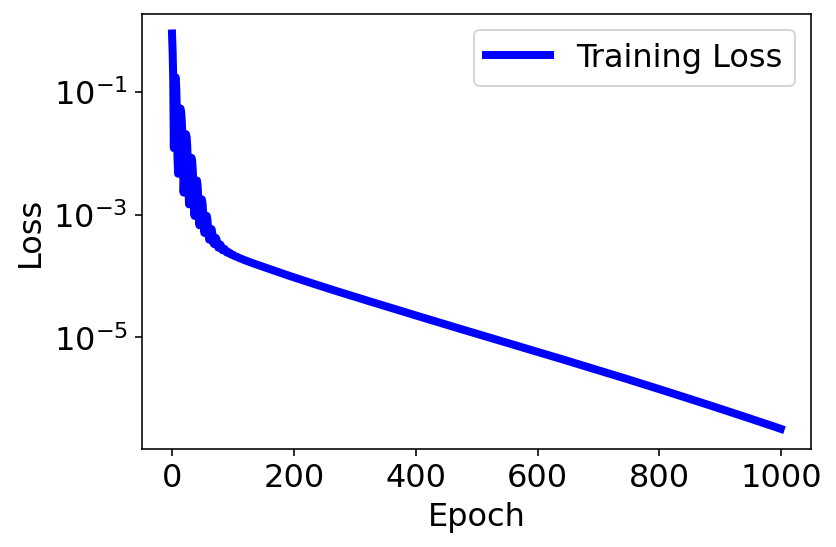

In [35]:
plt.plot(train_ls, linewidth=4, color='b', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.yscale('log')
plt.show()

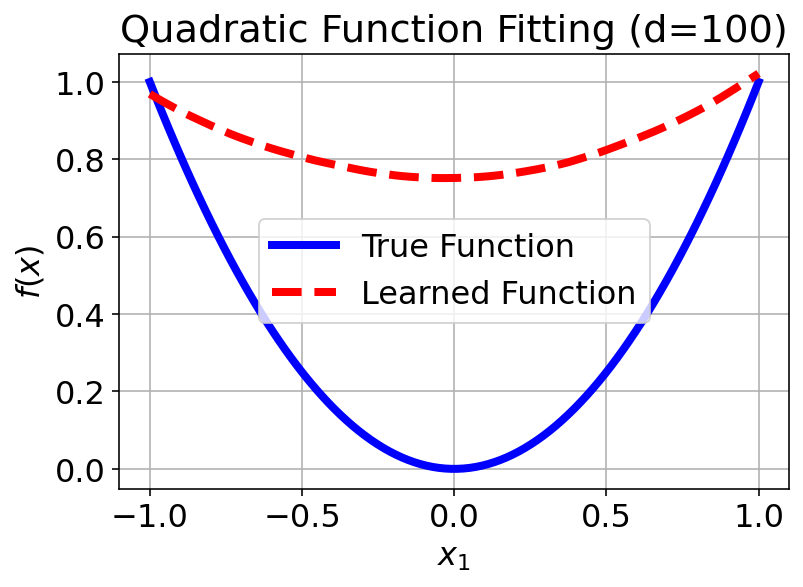

In [33]:
def generate_test_data(d, n_points):
    # 在第一个维度上生成等间隔的测试点
    x_test = np.zeros((n_points, d))
    x_test[:, 0] = np.linspace(-1, 1, n_points)
    
    # 计算真实的二次函数值
    y_test = x_test[:, 0]**2
    
    return x_test, y_test
d = 100
n_test = 100
x_test, y_test = generate_test_data(d, n_test)
# 在测试点上评估神经网络
with torch.no_grad():
    y_pred = model(torch.from_numpy(x_test).float()).numpy()
# 可视化结果
# plt.figure(figsize=(8, 5))
set_figsize()
plt.plot(x_test[:, 0], y_test, 'b-', lw=4, label='True Function')
plt.plot(x_test[:, 0], y_pred, 'r--', lw=4, label='Learned Function')
plt.xlabel('$x_1$')
plt.ylabel('$f(x)$')
plt.title(f'Quadratic Function Fitting (d={d})')
plt.legend()
plt.grid(True)
# plt.savefig('quadratic-predict.pdf', bbox_inches='tight')
# plt.savefig('name.svg', bbox_inches='tight')
plt.show()


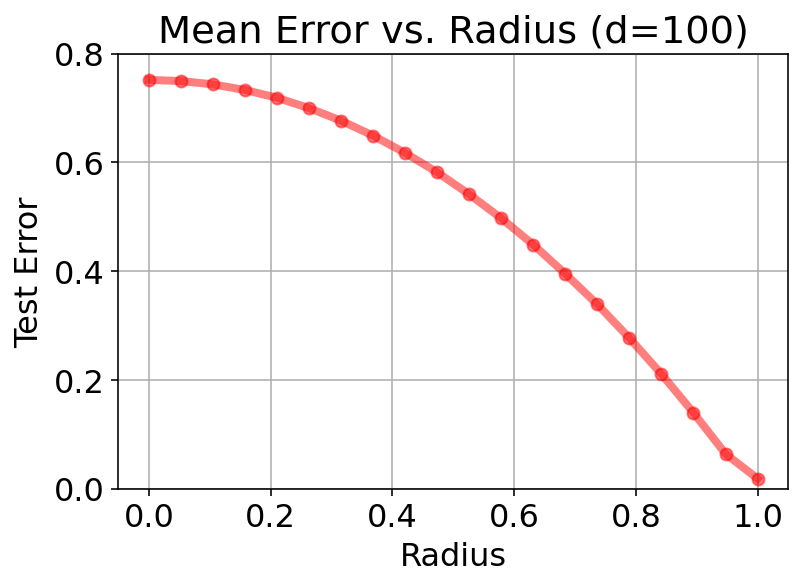

In [36]:
def generate_test_data(d, n_test, n_radii):
    # 生成均匀分布的半径值
    radii = np.linspace(0, 1, n_radii)
    # 在每个半径上随机采样点
    x_test = []
    y_test = []
    for r in radii:
        # 在d维球面上随机采样点
        x_surface = np.random.randn(n_test, d)
        x_surface_norm = np.linalg.norm(x_surface, axis=1)
        x_surface = x_surface / x_surface_norm[:, np.newaxis]
        # 将球面上的点缩放到指定半径
        x_surface *= r
        # 生成二次函数的目标值
        y_surface = np.sum(x_surface**2, axis=1, keepdims=True)
        
        x_test.append(x_surface)
        y_test.append(y_surface)
    
    x_test = np.concatenate(x_test, axis=0)
    y_test = np.concatenate(y_test, axis=0)
    
    return x_test, y_test, radii

n_test = 1000  # 每个半径上的测试样本数
n_radii = 20  # 半径的数量
x_test, y_test, radii = generate_test_data(d, n_test, n_radii)
errors = compute_errors(model, x_test, y_test)

# 计算每个半径上的平均误差
mean_errors = []
for i in range(n_radii):
    start_idx = i * n_test
    end_idx = (i + 1) * n_test
    mean_error = np.mean(errors[start_idx:end_idx])
    mean_errors.append(mean_error)

# plt.figure(figsize=(8, 5))
set_figsize()
plt.plot(radii, mean_errors, 'o-', c='r', lw=4, alpha=0.5)
plt.xlabel('Radius')
plt.ylabel('Test Error')
plt.title(f'Mean Error vs. Radius (d={d})')
plt.grid(True)
plt.ylim(0, 0.8)
# plt.savefig('volume-error.pdf', bbox_inches='tight')
# plt.savefig('name.svg', bbox_inches='tight')
# plt.yscale('log')
plt.show()

## 距离和角度的集中性

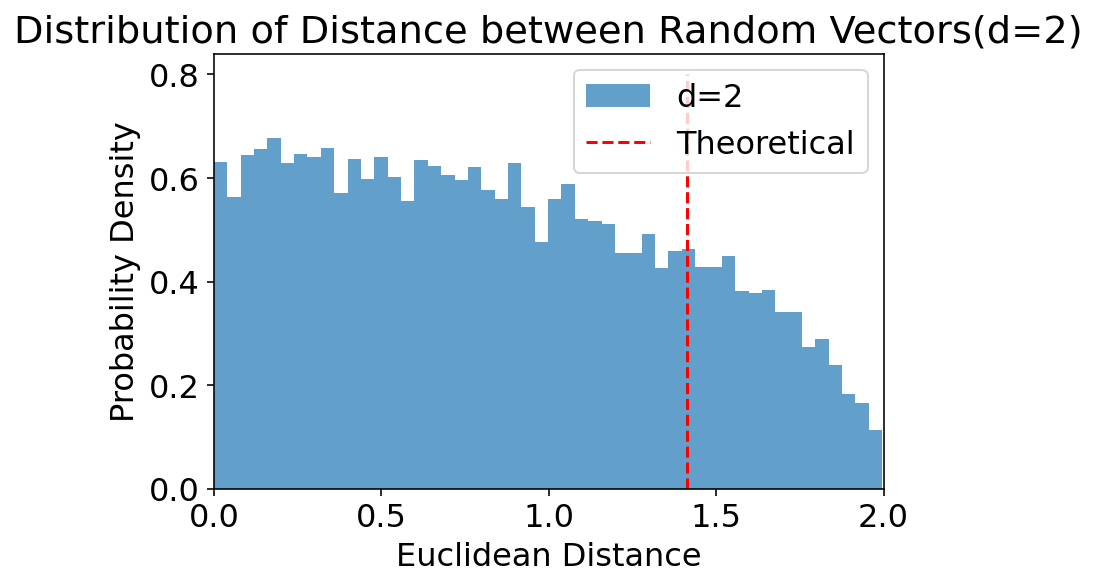

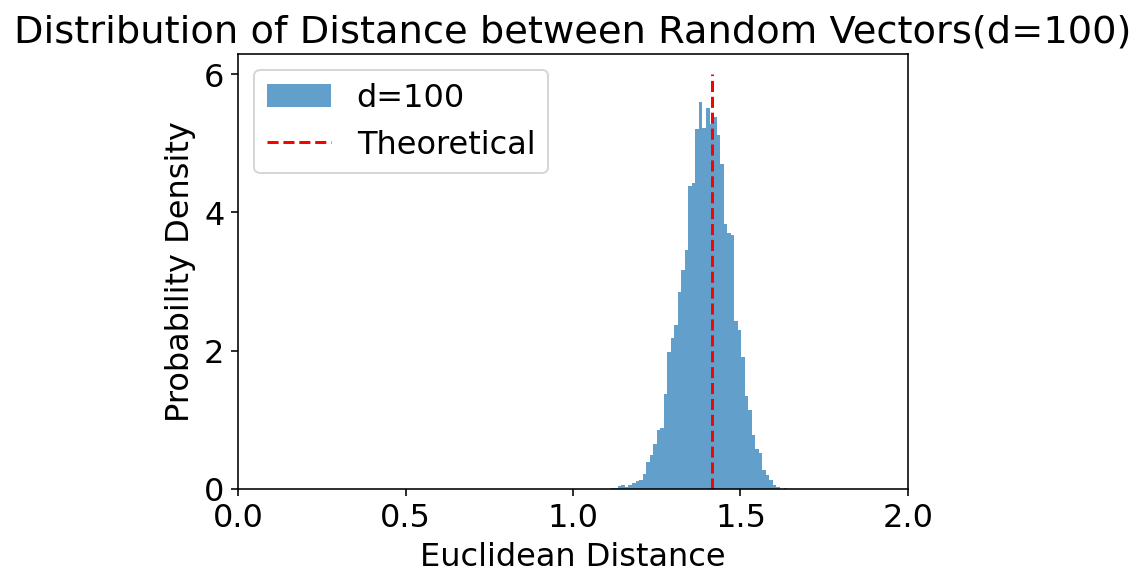

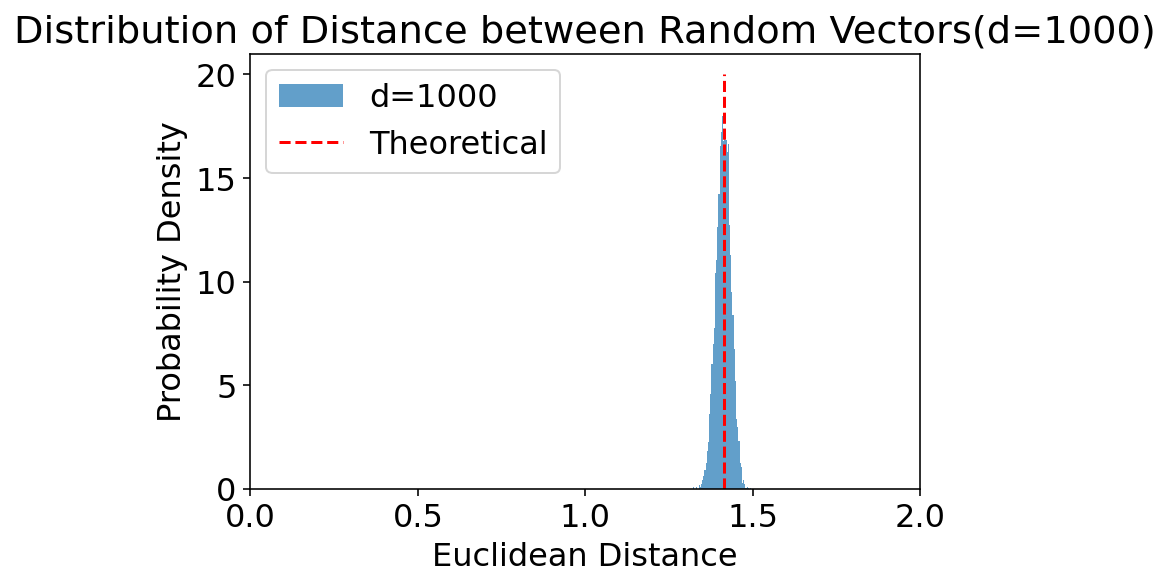

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 实验1:随机采样点对之间欧氏距离的分布
def experiment_1(d_values, n_samples=10000):
    for d in d_values:
        # 在d维单位球内随机采样点对
        x = np.random.randn(n_samples, d)
        y = np.random.randn(n_samples, d)
        x_norm = np.linalg.norm(x, axis=1)
        y_norm = np.linalg.norm(y, axis=1)
        u = np.random.rand(n_samples) ** (1/d)
        x = x * u[:, np.newaxis] / x_norm[:, np.newaxis]
        y = y * u[:, np.newaxis] / y_norm[:, np.newaxis]
        distances = np.sqrt(np.sum((x - y)**2, axis=1))
        set_figsize()
        plt.hist(distances, bins=50, density=True, alpha=0.7, label=f'd={d}')
        
        plt.xlabel('Euclidean Distance')
        plt.ylabel('Probability Density')
        plt.title(f'Distribution of Distance between Random Vectors(d={d})')
        if d == 2:
            plt.vlines(np.sqrt(2), 0, 0.8, 'r', '--', label='Theoretical')
        if d == 100:
            plt.vlines(np.sqrt(2), 0, 6, 'r', '--', label='Theoretical')
        if d == 1000:
            plt.vlines(np.sqrt(2), 0, 20, 'r', '--', label='Theoretical')
        plt.legend()
        plt.xlim(0, 2)
        # plt.savefig(f'distance-{d}.pdf', bbox_inches='tight')
        plt.show()
d_values = [2, 100, 1000]
experiment_1(d_values)


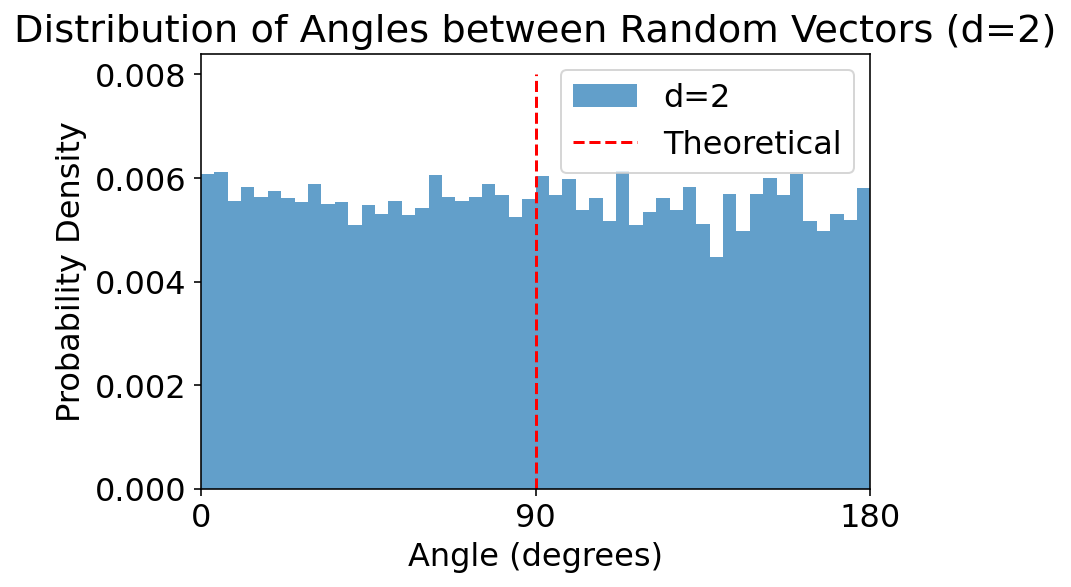

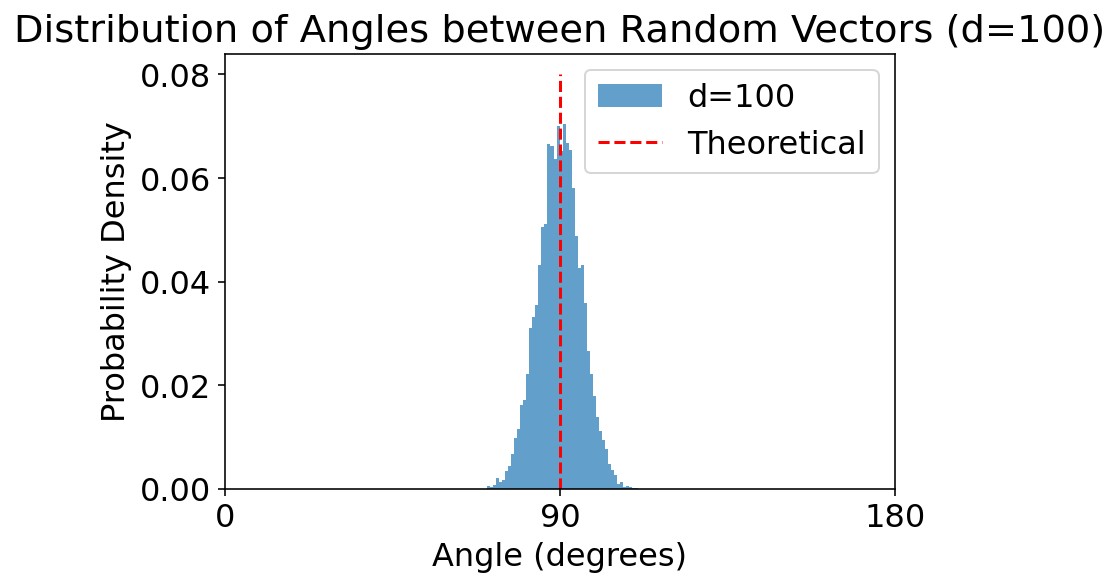

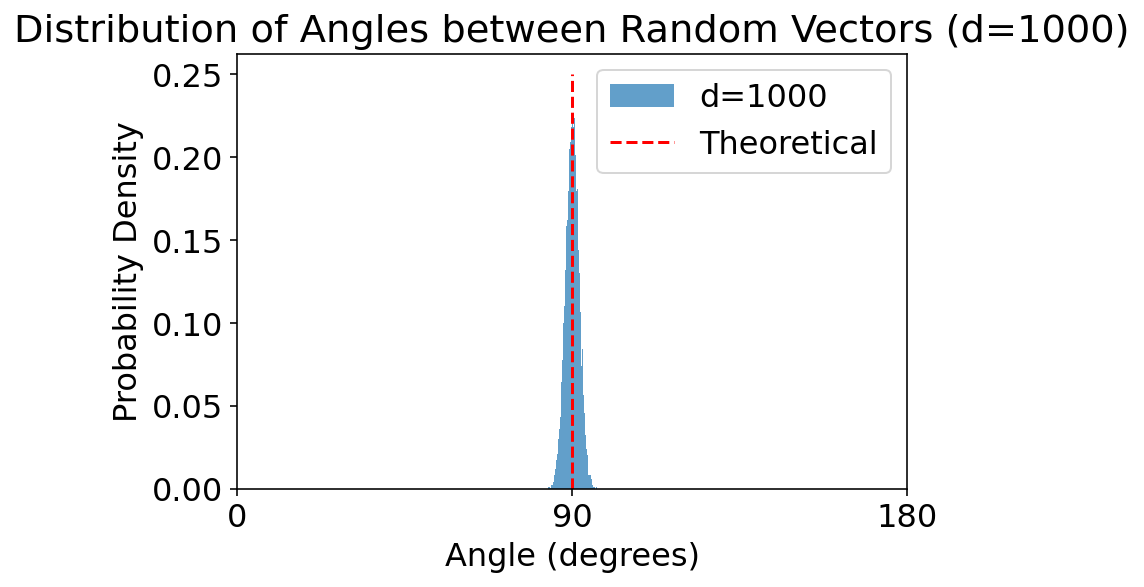

In [19]:
# 实验2:随机采样向量之间夹角的分布  
def experiment_2(d_values, n_samples=10000):
    for d in d_values:
        # 在d维单位球内随机采样点对
        x = np.random.uniform(-1, 1, (n_samples, d))
        y = np.random.uniform(-1, 1, (n_samples, d))
        x_norm = np.linalg.norm(x, axis=1)
        y_norm = np.linalg.norm(y, axis=1)
        x = x / x_norm[:, np.newaxis]
        y = y / y_norm[:, np.newaxis]
        
        cosine_similarity = np.sum(x * y, axis=1)
        angles = np.arccos(cosine_similarity) * 180 / np.pi
        
        # plt.figure(figsize=(8, 5))
        set_figsize()
        plt.hist(angles, bins=50, density=True, alpha=0.7, label=f'd={d}')
        if d == 2:
            plt.vlines(90, 0, 0.008, 'r', '--', label='Theoretical')
        if d == 100:
            plt.vlines(90, 0, 0.08, 'r', '--', label='Theoretical')
        if d == 1000:
            plt.vlines(90, 0, 0.25, 'r', '--', label='Theoretical')
        
        plt.xlabel('Angle (degrees)')
        plt.ylabel('Probability Density')
        plt.title(f'Distribution of Angles between Random Vectors (d={d})')
        plt.legend()
        plt.xlim(0, 180)
        plt.xticks([0, 90, 180], [0, 90, 180])
        # plt.savefig(f'angle-{d}.pdf', bbox_inches='tight')
        plt.show()

# 运行实验
d_values = [2, 100, 1000]
experiment_2(d_values)

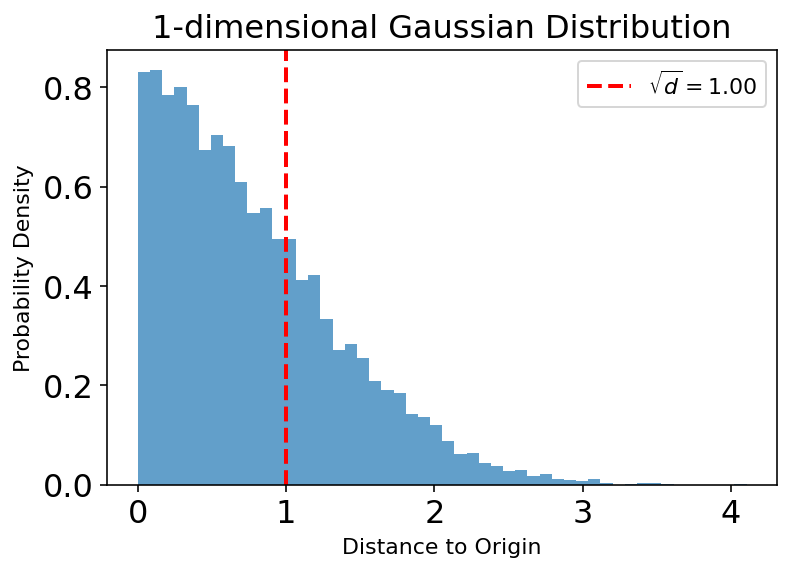

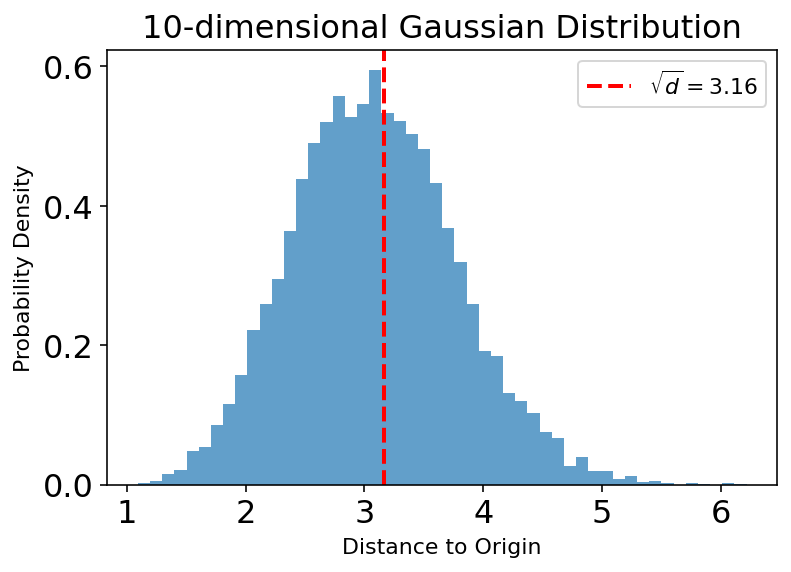

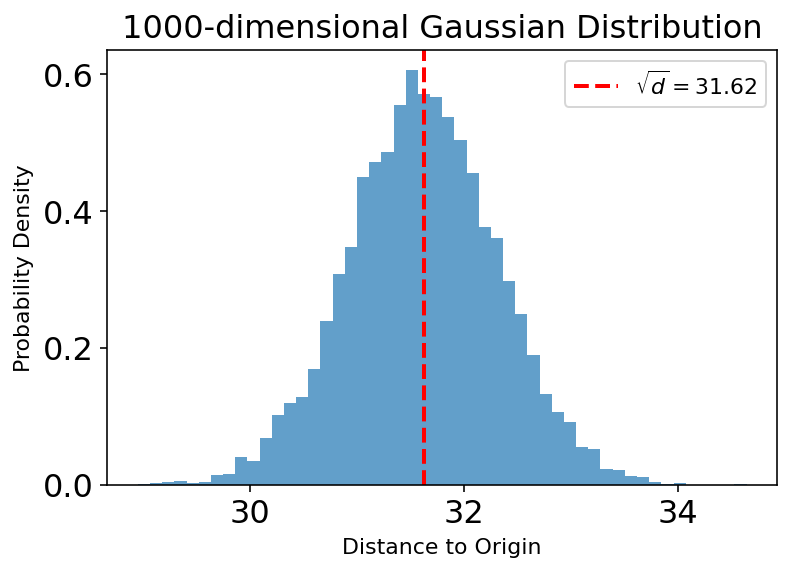

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_shell_theorem(d, n_samples):
    # 生成高维高斯分布的随机样本
    samples = np.random.multivariate_normal(np.zeros(d), np.eye(d), size=n_samples)
    
    # 计算样本到原点的距离
    distances = np.linalg.norm(samples, axis=1)
    
    # 绘制距离的分布直方图
    plt.figure()
    set_figsize()
    plt.hist(distances, bins=50, density=True, alpha=0.7)
    plt.axvline(np.sqrt(d), color='r', linestyle='--', linewidth=2, label=f'$\sqrt{{d}}={np.sqrt(d):.2f}$')
    plt.xlabel('Distance to Origin', fontsize=11)
    plt.ylabel('Probability Density', fontsize=11)
    plt.title(f'{d}-dimensional Gaussian Distribution', fontsize=16)
    plt.legend(fontsize=11)
    # plt.grid(True)
    # plt.show()

# 设置实验参数
d = 1  # 高斯分布的维度
n_samples = 10000  # 随机样本数
# 运行实验
gaussian_shell_theorem(d, n_samples)

d = 10  # 高斯分布的维度
n_samples = 10000  # 随机样本数

# 运行实验
gaussian_shell_theorem(d, n_samples)
d = 1000  # 高斯分布的维度
n_samples = 10000  # 随机样本数

# 运行实验
gaussian_shell_theorem(d, n_samples)
